# Occupancy Networks for Synthetic Peptides
Implementation based on: https://github.com/autonomousvision/occupancy_networks

**Paper:** "Occupancy Networks: 3D Reconstruction in Function Space" (Mescheder et al., CVPR 2019)

**Architecture:**
- **Encoder**: Image encoder (ResNet18 by default) for visual feature extraction
- **Decoder**: Fully-connected ResNet blocks with latent code conditioning
- **Latent Code**: Optional latent variables for shape diversity
- **Training**: Query-based occupancy prediction with optional latent inference

In [77]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import sys
import importlib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import distributions as dist
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
from pathlib import Path

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.4.1
CUDA available: True
CUDA version: 12.0
GPU: NVIDIA GeForce RTX 2080 Ti


## Module Integration: Import occupancy_networks Code

In [78]:
# ============================================================================
# OCCUPANCY NETWORK IMPLEMENTATION (copied from occupancy_networks module)
# ============================================================================

# ---- LAYER DEFINITIONS (from im2mesh.layers) ----

class ResnetBlockFC(nn.Module):
    ''' Fully connected ResNet Block class. '''
    def __init__(self, size_in, size_out=None, size_h=None):
        super().__init__()
        if size_out is None:
            size_out = size_in
        if size_h is None:
            size_h = min(size_in, size_out)
        self.size_in = size_in
        self.size_h = size_h
        self.size_out = size_out
        self.fc_0 = nn.Linear(size_in, size_h)
        self.fc_1 = nn.Linear(size_h, size_out)
        self.actvn = nn.ReLU()
        if size_in == size_out:
            self.shortcut = None
        else:
            self.shortcut = nn.Linear(size_in, size_out, bias=False)
        nn.init.zeros_(self.fc_1.weight)

    def forward(self, x):
        net = self.fc_0(self.actvn(x))
        dx = self.fc_1(self.actvn(net))
        if self.shortcut is not None:
            x_s = self.shortcut(x)
        else:
            x_s = x
        return x_s + dx


class CResnetBlockConv1d(nn.Module):
    ''' Conditional batch normalization-based Resnet block class. '''
    def __init__(self, c_dim, size_in, size_h=None, size_out=None,
                 norm_method='batch_norm', legacy=False):
        super().__init__()
        if size_h is None:
            size_h = size_in
        if size_out is None:
            size_out = size_in
        self.size_in = size_in
        self.size_h = size_h
        self.size_out = size_out
        if not legacy:
            self.bn_0 = CBatchNorm1d(c_dim, size_in, norm_method=norm_method)
            self.bn_1 = CBatchNorm1d(c_dim, size_h, norm_method=norm_method)
        else:
            self.bn_0 = CBatchNorm1d_legacy(c_dim, size_in, norm_method=norm_method)
            self.bn_1 = CBatchNorm1d_legacy(c_dim, size_h, norm_method=norm_method)
        self.fc_0 = nn.Conv1d(size_in, size_h, 1)
        self.fc_1 = nn.Conv1d(size_h, size_out, 1)
        self.actvn = nn.ReLU()
        if size_in == size_out:
            self.shortcut = None
        else:
            self.shortcut = nn.Conv1d(size_in, size_out, 1, bias=False)
        nn.init.zeros_(self.fc_1.weight)

    def forward(self, x, c):
        net = self.fc_0(self.actvn(self.bn_0(x, c)))
        dx = self.fc_1(self.actvn(self.bn_1(net, c)))
        if self.shortcut is not None:
            x_s = self.shortcut(x)
        else:
            x_s = x
        return x_s + dx


class ResnetBlockConv1d(nn.Module):
    ''' 1D-Convolutional ResNet block class. '''
    def __init__(self, size_in, size_h=None, size_out=None):
        super().__init__()
        if size_h is None:
            size_h = size_in
        if size_out is None:
            size_out = size_in
        self.size_in = size_in
        self.size_h = size_h
        self.size_out = size_out
        self.bn_0 = nn.BatchNorm1d(size_in)
        self.bn_1 = nn.BatchNorm1d(size_h)
        self.fc_0 = nn.Conv1d(size_in, size_h, 1)
        self.fc_1 = nn.Conv1d(size_h, size_out, 1)
        self.actvn = nn.ReLU()
        if size_in == size_out:
            self.shortcut = None
        else:
            self.shortcut = nn.Conv1d(size_in, size_out, 1, bias=False)
        nn.init.zeros_(self.fc_1.weight)

    def forward(self, x):
        net = self.fc_0(self.actvn(self.bn_0(x)))
        dx = self.fc_1(self.actvn(self.bn_1(net)))
        if self.shortcut is not None:
            x_s = self.shortcut(x)
        else:
            x_s = x
        return x_s + dx


class CBatchNorm1d(nn.Module):
    ''' Conditional batch normalization layer class. '''
    def __init__(self, c_dim, f_dim, norm_method='batch_norm'):
        super().__init__()
        self.c_dim = c_dim
        self.f_dim = f_dim
        self.norm_method = norm_method
        self.conv_gamma = nn.Conv1d(c_dim, f_dim, 1)
        self.conv_beta = nn.Conv1d(c_dim, f_dim, 1)
        if norm_method == 'batch_norm':
            self.bn = nn.BatchNorm1d(f_dim, affine=False)
        elif norm_method == 'instance_norm':
            self.bn = nn.InstanceNorm1d(f_dim, affine=False)
        elif norm_method == 'group_norm':
            self.bn = nn.GroupNorm(f_dim, f_dim, affine=False)
        else:
            raise ValueError('Invalid normalization method!')
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.zeros_(self.conv_gamma.weight)
        nn.init.zeros_(self.conv_beta.weight)
        nn.init.ones_(self.conv_gamma.bias)
        nn.init.zeros_(self.conv_beta.bias)

    def forward(self, x, c):
        assert(x.size(0) == c.size(0))
        assert(c.size(1) == self.c_dim)
        if len(c.size()) == 2:
            c = c.unsqueeze(2)
        gamma = self.conv_gamma(c)
        beta = self.conv_beta(c)
        net = self.bn(x)
        out = gamma * net + beta
        return out


class CBatchNorm1d_legacy(nn.Module):
    ''' Conditional batch normalization legacy layer class. '''
    def __init__(self, c_dim, f_dim, norm_method='batch_norm'):
        super().__init__()
        self.c_dim = c_dim
        self.f_dim = f_dim
        self.norm_method = norm_method
        self.fc_gamma = nn.Linear(c_dim, f_dim)
        self.fc_beta = nn.Linear(c_dim, f_dim)
        if norm_method == 'batch_norm':
            self.bn = nn.BatchNorm1d(f_dim, affine=False)
        elif norm_method == 'instance_norm':
            self.bn = nn.InstanceNorm1d(f_dim, affine=False)
        elif norm_method == 'group_norm':
            self.bn = nn.GroupNorm(f_dim, f_dim, affine=False)
        else:
            raise ValueError('Invalid normalization method!')
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.zeros_(self.fc_gamma.weight)
        nn.init.zeros_(self.fc_beta.weight)
        nn.init.ones_(self.fc_gamma.bias)
        nn.init.zeros_(self.fc_beta.bias)

    def forward(self, x, c):
        batch_size = x.size(0)
        gamma = self.fc_gamma(c)
        beta = self.fc_beta(c)
        gamma = gamma.view(batch_size, self.f_dim, 1)
        beta = beta.view(batch_size, self.f_dim, 1)
        net = self.bn(x)
        out = gamma * net + beta
        return out


# ---- DECODER IMPLEMENTATIONS ----

class Decoder(nn.Module):
    ''' Decoder class without normalization. '''
    def __init__(self, dim=3, z_dim=128, c_dim=128,
                 hidden_size=128, leaky=False):
        super().__init__()
        self.z_dim = z_dim
        self.c_dim = c_dim
        self.fc_p = nn.Linear(dim, hidden_size)
        if not z_dim == 0:
            self.fc_z = nn.Linear(z_dim, hidden_size)
        if not c_dim == 0:
            self.fc_c = nn.Linear(c_dim, hidden_size)
        self.block0 = ResnetBlockFC(hidden_size)
        self.block1 = ResnetBlockFC(hidden_size)
        self.block2 = ResnetBlockFC(hidden_size)
        self.block3 = ResnetBlockFC(hidden_size)
        self.block4 = ResnetBlockFC(hidden_size)
        self.fc_out = nn.Linear(hidden_size, 1)
        if not leaky:
            self.actvn = F.relu
        else:
            self.actvn = lambda x: F.leaky_relu(x, 0.2)

    def forward(self, p, z, c=None, **kwargs):
        batch_size, T, D = p.size()
        net = self.fc_p(p)
        if self.z_dim != 0:
            net_z = self.fc_z(z).unsqueeze(1)
            net = net + net_z
        if self.c_dim != 0:
            net_c = self.fc_c(c).unsqueeze(1)
            net = net + net_c
        net = self.block0(net)
        net = self.block1(net)
        net = self.block2(net)
        net = self.block3(net)
        net = self.block4(net)
        out = self.fc_out(self.actvn(net))
        out = out.squeeze(-1)
        return out


class DecoderCBatchNorm(nn.Module):
    ''' Decoder with conditional batch normalization (CBN) class. '''
    def __init__(self, dim=3, z_dim=128, c_dim=128,
                 hidden_size=256, leaky=False, legacy=False):
        super().__init__()
        self.z_dim = z_dim
        if not z_dim == 0:
            self.fc_z = nn.Linear(z_dim, hidden_size)
        self.fc_p = nn.Conv1d(dim, hidden_size, 1)
        self.block0 = CResnetBlockConv1d(c_dim, hidden_size, legacy=legacy)
        self.block1 = CResnetBlockConv1d(c_dim, hidden_size, legacy=legacy)
        self.block2 = CResnetBlockConv1d(c_dim, hidden_size, legacy=legacy)
        self.block3 = CResnetBlockConv1d(c_dim, hidden_size, legacy=legacy)
        self.block4 = CResnetBlockConv1d(c_dim, hidden_size, legacy=legacy)
        if not legacy:
            self.bn = CBatchNorm1d(c_dim, hidden_size)
        else:
            self.bn = CBatchNorm1d_legacy(c_dim, hidden_size)
        self.fc_out = nn.Conv1d(hidden_size, 1, 1)
        if not leaky:
            self.actvn = F.relu
        else:
            self.actvn = lambda x: F.leaky_relu(x, 0.2)

    def forward(self, p, z, c, **kwargs):
        p = p.transpose(1, 2)
        batch_size, D, T = p.size()
        net = self.fc_p(p)
        if self.z_dim != 0:
            net_z = self.fc_z(z).unsqueeze(2)
            net = net + net_z
        net = self.block0(net, c)
        net = self.block1(net, c)
        net = self.block2(net, c)
        net = self.block3(net, c)
        net = self.block4(net, c)
        out = self.fc_out(self.actvn(self.bn(net, c)))
        out = out.squeeze(1)
        return out


class DecoderCBatchNorm2(nn.Module):
    ''' Decoder with CBN class 2. '''
    def __init__(self, dim=3, z_dim=0, c_dim=128,
                 hidden_size=256, n_blocks=5):
        super().__init__()
        self.z_dim = z_dim
        if z_dim != 0:
            self.fc_z = nn.Linear(z_dim, c_dim)
        self.conv_p = nn.Conv1d(dim, hidden_size, 1)
        self.blocks = nn.ModuleList([
            CResnetBlockConv1d(c_dim, hidden_size) for i in range(n_blocks)
        ])
        self.bn = CBatchNorm1d(c_dim, hidden_size)
        self.conv_out = nn.Conv1d(hidden_size, 1, 1)
        self.actvn = nn.ReLU()

    def forward(self, p, z, c, **kwargs):
        p = p.transpose(1, 2)
        batch_size, D, T = p.size()
        net = self.conv_p(p)
        if self.z_dim != 0:
            c = c + self.fc_z(z)
        for block in self.blocks:
            net = block(net, c)
        out = self.conv_out(self.actvn(self.bn(net, c)))
        out = out.squeeze(1)
        return out


class DecoderCBatchNormNoResnet(nn.Module):
    ''' Decoder CBN with no ResNet blocks class. '''
    def __init__(self, dim=3, z_dim=128, c_dim=128,
                 hidden_size=256, leaky=False):
        super().__init__()
        self.z_dim = z_dim
        if not z_dim == 0:
            self.fc_z = nn.Linear(z_dim, hidden_size)
        self.fc_p = nn.Conv1d(dim, hidden_size, 1)
        self.fc_0 = nn.Conv1d(hidden_size, hidden_size, 1)
        self.fc_1 = nn.Conv1d(hidden_size, hidden_size, 1)
        self.fc_2 = nn.Conv1d(hidden_size, hidden_size, 1)
        self.fc_3 = nn.Conv1d(hidden_size, hidden_size, 1)
        self.fc_4 = nn.Conv1d(hidden_size, hidden_size, 1)
        self.bn_0 = CBatchNorm1d(c_dim, hidden_size)
        self.bn_1 = CBatchNorm1d(c_dim, hidden_size)
        self.bn_2 = CBatchNorm1d(c_dim, hidden_size)
        self.bn_3 = CBatchNorm1d(c_dim, hidden_size)
        self.bn_4 = CBatchNorm1d(c_dim, hidden_size)
        self.bn_5 = CBatchNorm1d(c_dim, hidden_size)
        self.fc_out = nn.Conv1d(hidden_size, 1, 1)
        if not leaky:
            self.actvn = F.relu
        else:
            self.actvn = lambda x: F.leaky_relu(x, 0.2)

    def forward(self, p, z, c, **kwargs):
        p = p.transpose(1, 2)
        batch_size, D, T = p.size()
        net = self.fc_p(p)
        if self.z_dim != 0:
            net_z = self.fc_z(z).unsqueeze(2)
            net = net + net_z
        net = self.actvn(self.bn_0(net, c))
        net = self.fc_0(net)
        net = self.actvn(self.bn_1(net, c))
        net = self.fc_1(net)
        net = self.actvn(self.bn_2(net, c))
        net = self.fc_2(net)
        net = self.actvn(self.bn_3(net, c))
        net = self.fc_3(net)
        net = self.actvn(self.bn_4(net, c))
        net = self.fc_4(net)
        net = self.actvn(self.bn_5(net, c))
        out = self.fc_out(net)
        out = out.squeeze(1)
        return out


class DecoderBatchNorm(nn.Module):
    ''' Decoder with batch normalization class. '''
    def __init__(self, dim=3, z_dim=128, c_dim=128,
                 hidden_size=256, leaky=False):
        super().__init__()
        self.z_dim = z_dim
        self.c_dim = c_dim
        if not z_dim == 0:
            self.fc_z = nn.Linear(z_dim, hidden_size)
        if self.c_dim != 0:
            self.fc_c = nn.Linear(c_dim, hidden_size)
        self.fc_p = nn.Conv1d(dim, hidden_size, 1)
        self.block0 = ResnetBlockConv1d(hidden_size)
        self.block1 = ResnetBlockConv1d(hidden_size)
        self.block2 = ResnetBlockConv1d(hidden_size)
        self.block3 = ResnetBlockConv1d(hidden_size)
        self.block4 = ResnetBlockConv1d(hidden_size)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.fc_out = nn.Conv1d(hidden_size, 1, 1)
        if not leaky:
            self.actvn = F.relu
        else:
            self.actvn = lambda x: F.leaky_relu(x, 0.2)

    def forward(self, p, z, c, **kwargs):
        p = p.transpose(1, 2)
        batch_size, D, T = p.size()
        net = self.fc_p(p)
        if self.z_dim != 0:
            net_z = self.fc_z(z).unsqueeze(2)
            net = net + net_z
        if self.c_dim != 0:
            net_c = self.fc_c(c).unsqueeze(2)
            net = net + net_c
        net = self.block0(net)
        net = self.block1(net)
        net = self.block2(net)
        net = self.block3(net)
        net = self.block4(net)
        out = self.fc_out(self.actvn(self.bn(net)))
        out = out.squeeze(1)
        return out


# ---- LATENT ENCODER ----

def maxpool(x, dim=-1, keepdim=False):
    """Max pooling operation."""
    out, _ = x.max(dim=dim, keepdim=keepdim)
    return out


class LatentEncoder(nn.Module):
    ''' Latent encoder class. '''
    def __init__(self, z_dim=128, c_dim=128, dim=3, leaky=False):
        super().__init__()
        self.z_dim = z_dim
        self.c_dim = c_dim
        self.fc_pos = nn.Linear(dim, 128)
        if c_dim != 0:
            self.fc_c = nn.Linear(c_dim, 128)
        self.fc_0 = nn.Linear(1, 128)
        self.fc_1 = nn.Linear(128, 128)
        self.fc_2 = nn.Linear(256, 128)
        self.fc_3 = nn.Linear(256, 128)
        self.fc_mean = nn.Linear(128, z_dim)
        self.fc_logstd = nn.Linear(128, z_dim)
        if not leaky:
            self.actvn = F.relu
            self.pool = maxpool
        else:
            self.actvn = lambda x: F.leaky_relu(x, 0.2)
            self.pool = torch.mean

    def forward(self, p, x, c=None, **kwargs):
        batch_size, T, D = p.size()
        net = self.fc_0(x.unsqueeze(-1))
        net = net + self.fc_pos(p)
        if self.c_dim != 0:
            net = net + self.fc_c(c).unsqueeze(1)
        net = self.fc_1(self.actvn(net))
        pooled = self.pool(net, dim=1, keepdim=True).expand(net.size())
        net = torch.cat([net, pooled], dim=2)
        net = self.fc_2(self.actvn(net))
        pooled = self.pool(net, dim=1, keepdim=True).expand(net.size())
        net = torch.cat([net, pooled], dim=2)
        net = self.fc_3(self.actvn(net))
        net = self.pool(net, dim=1)
        mean = self.fc_mean(net)
        logstd = self.fc_logstd(net)
        return mean, logstd


# ---- OCCUPANCY NETWORK ----

class OccupancyNetwork(nn.Module):
    ''' Occupancy Network class. '''
    def __init__(self, decoder, encoder=None, encoder_latent=None, p0_z=None,
                 device=None):
        super().__init__()
        if p0_z is None:
            p0_z = dist.Normal(torch.tensor([]), torch.tensor([]))
        self.decoder = decoder.to(device)
        if encoder_latent is not None:
            self.encoder_latent = encoder_latent.to(device)
        else:
            self.encoder_latent = None
        if encoder is not None:
            self.encoder = encoder.to(device)
        else:
            self.encoder = None
        self._device = device
        self.p0_z = p0_z

    def forward(self, p, inputs, sample=True, **kwargs):
        batch_size = p.size(0)
        c = self.encode_inputs(inputs)
        z = self.get_z_from_prior((batch_size,), sample=sample)
        p_r = self.decode(p, z, c, **kwargs)
        return p_r

    def compute_elbo(self, p, occ, inputs, **kwargs):
        c = self.encode_inputs(inputs)
        q_z = self.infer_z(p, occ, c, **kwargs)
        z = q_z.rsample()
        p_r = self.decode(p, z, c, **kwargs)
        rec_error = -p_r.log_prob(occ).sum(dim=-1)
        kl = dist.kl_divergence(q_z, self.p0_z).sum(dim=-1)
        elbo = -rec_error - kl
        return elbo, rec_error, kl

    def encode_inputs(self, inputs):
        if self.encoder is not None:
            c = self.encoder(inputs)
        else:
            c = torch.empty(inputs.size(0), 0)
        return c

    def decode(self, p, z, c, **kwargs):
        logits = self.decoder(p, z, c, **kwargs)
        p_r = dist.Bernoulli(logits=logits)
        return p_r

    def infer_z(self, p, occ, c, **kwargs):
        if self.encoder_latent is not None:
            mean_z, logstd_z = self.encoder_latent(p, occ, c, **kwargs)
        else:
            batch_size = p.size(0)
            mean_z = torch.empty(batch_size, 0).to(self._device)
            logstd_z = torch.empty(batch_size, 0).to(self._device)
        q_z = dist.Normal(mean_z, torch.exp(logstd_z))
        return q_z

    def get_z_from_prior(self, size=torch.Size([]), sample=True):
        if sample:
            z = self.p0_z.sample(size).to(self._device)
        else:
            z = self.p0_z.mean.to(self._device)
            z = z.expand(*size, *z.size())
        return z

    def to(self, device):
        model = super().to(device)
        model._device = device
        return model


# Import peptide dataset
import synthetic_peptides_dataset
importlib.reload(synthetic_peptides_dataset)
from synthetic_peptides_dataset import SyntheticPeptidesDataset

print("✓ ONet implementation loaded and module integration complete")

✓ ONet implementation loaded and module integration complete


## Configuration and Reproducibility

In [114]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Run configuration (official unconditional ONet setup for peptide dataset)
config_dict = {
    'run_name': 'onet_peptides_uncond_official',
    'train_data_path': './data/synthetic_peptides_split/train',
    'val_data_path': './data/synthetic_peptides_split/val',
    'test_data_path': './data/synthetic_peptides_split/test',
    
    # Dataset
    'grid_size': 64,
    'num_query_points': 10000,
    'occupancy_threshold': 0.04,
    'train_num_files': 1,
    'val_num_files': 1,
    
    # Official unconditional ONet-style model
    'z_dim': 128,
    'decoder_hidden_size': 256,
    
    # Training
    'batch_size': 1,
    'learning_rate': 1e-5,
    'epochs': 2000,
    'save_every': 10,
    'val_interval': 500,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Run name: {config_dict['run_name']}")
print(f"Config: {json.dumps(config_dict, indent=2)}")

Device: cuda
Run name: onet_peptides_uncond_official
Config: {
  "run_name": "onet_peptides_uncond_official",
  "train_data_path": "./data/synthetic_peptides_split/train",
  "val_data_path": "./data/synthetic_peptides_split/val",
  "test_data_path": "./data/synthetic_peptides_split/test",
  "grid_size": 64,
  "num_query_points": 10000,
  "occupancy_threshold": 0.04,
  "train_num_files": 1,
  "val_num_files": 1,
  "z_dim": 128,
  "decoder_hidden_size": 256,
  "batch_size": 1,
  "learning_rate": 1e-05,
  "epochs": 2000,
  "save_every": 10,
  "val_interval": 500
}


## Dataset for Peptides

In [167]:
def points_to_voxels(points, grid_size=32):
    """Convert peptide centroid point cloud to occupancy grid."""
    voxel_grid = np.zeros((grid_size, grid_size, grid_size), dtype=np.float32)
    points_norm = points + 0.5  # from [-0.5, 0.5] -> [0, 1]
    indices = (points_norm * (grid_size - 1)).astype(int)
    indices = np.clip(indices, 0, grid_size - 1)
    voxel_grid[indices[:, 0], indices[:, 1], indices[:, 2]] = 1.0
    return voxel_grid


class PeptideDataset(Dataset):
    """Dataset for peptide assemblies using one centroid point per peptide."""

    def __init__(
        self,
        data_path='./data/synthetic_peptides',
        grid_size=64,
        num_query_points=2000,
        num_files=None,
        structure_types=None,
        occupancy_threshold=0.02,
        target_num_points=None,
        seed=None,
    ):
        self.grid_size = grid_size
        self.num_query_points = num_query_points
        self.occupancy_threshold = occupancy_threshold

        self.base_dataset = SyntheticPeptidesDataset(
            data_path=data_path,
            structure_types=structure_types,
            num_files=num_files,
            target_num_points=target_num_points,
            normalize=True,
            return_peptide_ids=True,
            seed=seed,
        )

        self.files = self.base_dataset.files
        self.file_types = self.base_dataset.file_types

        print(
            f"Peptide dataset ready: {len(self.files)} files, "
            f"grid={grid_size}^3, query_points={num_query_points}, "
            f"threshold={occupancy_threshold}"
        )

    def __len__(self):
        return len(self.base_dataset)

    def get_centroid_points(self, idx):
        sample = self.base_dataset[idx]
        centroid_points = sample['points'].cpu().numpy()
        peptide_ids = sample['peptide_ids'].cpu().numpy()
        mask = sample['mask'].cpu().numpy().astype(bool)
        return centroid_points[mask], peptide_ids[mask]

    def __getitem__(self, idx):
        try:
            centroid_points, _ = self.get_centroid_points(idx)
            if len(centroid_points) == 0:
                raise ValueError('No peptide centroids found')

            voxel_grid = points_to_voxels(centroid_points, self.grid_size)
            voxel_tensor = torch.tensor(voxel_grid, dtype=torch.float32).unsqueeze(0)

            query_points = torch.rand(self.num_query_points, 3) - 0.5
            centroid_tensor = torch.tensor(centroid_points, dtype=torch.float32)
            dists = torch.cdist(query_points, centroid_tensor)
            min_dists = dists.min(dim=1)[0]
            occupancy = (min_dists < self.occupancy_threshold).float()

            return {
                'voxel': voxel_tensor,
                'query_points': query_points,
                'occupancy': occupancy,
                'idx': idx
            }

        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            return {
                'voxel': torch.zeros(1, self.grid_size, self.grid_size, self.grid_size),
                'query_points': torch.rand(self.num_query_points, 3) - 0.5,
                'occupancy': torch.zeros(self.num_query_points),
                'idx': idx
            }


# Instantiate datasets
train_dataset = PeptideDataset(
    data_path=config_dict['train_data_path'],
    grid_size=config_dict['grid_size'],
    num_query_points=config_dict['num_query_points'],
    num_files=config_dict['train_num_files'],
    occupancy_threshold=config_dict['occupancy_threshold'],
    structure_types=["nanotubes"],
)

val_dataset = PeptideDataset(
    data_path=config_dict['val_data_path'],
    grid_size=config_dict['grid_size'],
    num_query_points=config_dict['num_query_points'],
    num_files=config_dict['val_num_files'],
    occupancy_threshold=config_dict['occupancy_threshold'],
    structure_types=["nanotubes"],
)

train_loader = DataLoader(train_dataset, batch_size=config_dict['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=config_dict['batch_size'], shuffle=False, num_workers=0)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")

Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes
Selected files per structure:
  nanotubes: 1/700
Dataset ready: 1 files, target_points=None, normalize=True
Peptide dataset ready: 1 files, grid=64^3, query_points=10000, threshold=0.04
Loading centroid dataset from: ./data/synthetic_peptides_split/val
Structure types: nanotubes
Selected files per structure:
  nanotubes: 1/150
Dataset ready: 1 files, target_points=None, normalize=True
Peptide dataset ready: 1 files, grid=64^3, query_points=10000, threshold=0.04
Train loader: 1 batches
Val loader: 1 batches


In [172]:
# Visualize Occupancy Labeling
sample_idx = 0
sample = train_dataset[sample_idx]

query_points_np = sample['query_points'].numpy()
occupancy_np = sample['occupancy'].numpy()

# Separate occupied vs unoccupied points
occupied_mask = occupancy_np > 0.5
unoccupied_mask = occupancy_np < 0.5

occupied_points = query_points_np[occupied_mask]
unoccupied_points = query_points_np[unoccupied_mask]

print(f"Sample {sample_idx} occupancy distribution:")
print(f"  Occupied points (peptides=1): {occupied_mask.sum()} points")
print(f"  Unoccupied points (empty=0): {unoccupied_mask.sum()} points")

# Create 3D visualization with occupancy points
fig = go.Figure()

# Add occupied points (blue - peptides)
if len(occupied_points) > 0:
    fig.add_trace(go.Scatter3d(
        x=occupied_points[:, 0],
        y=occupied_points[:, 1],
        z=occupied_points[:, 2],
        mode='markers',
        name='Occupied (peptides=1)',
        marker=dict(size=4, color='blue', opacity=0.8)
    ))

# Add unoccupied points (gray - empty space)
if len(unoccupied_points) > 0:
    fig.add_trace(go.Scatter3d(
        x=unoccupied_points[:, 0],
        y=unoccupied_points[:, 1],
        z=unoccupied_points[:, 2],
        mode='markers',
        name='Unoccupied (empty=0)',
        marker=dict(size=2, color='red', opacity=0.3)
    ))

fig.update_layout(
    title=f'Occupancy Visualization - Sample {sample_idx}',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data',
    ),
    width=900,
    height=700,
    hovermode='closest'
)
fig.show()

print(f"\n✓ Occupancy visualization complete")
print(f"✓ Blue points = actual peptide centroids (occupancy=1)")
print(f"✓ Gray points = random empty space (occupancy=0)")

Sample 0 occupancy distribution:
  Occupied points (peptides=1): 784 points
  Unoccupied points (empty=0): 9216 points



✓ Occupancy visualization complete
✓ Blue points = actual peptide centroids (occupancy=1)
✓ Gray points = random empty space (occupancy=0)


In [149]:
print(f"\n✓ Blue points = actual peptide centroid locations (occupied = 1)")
print(f"✓ Gray points = random empty space (occupied = 0)")


✓ Blue points = actual peptide centroid locations (occupied = 1)
✓ Gray points = random empty space (occupied = 0)


## Loss Functions and Metrics

In [151]:
def focal_loss_from_probs(probs, targets, alpha=0.25, gamma=2.0, eps=1e-8):
    """Focal loss for class imbalance."""
    probs = torch.clamp(probs, eps, 1.0 - eps)
    targets = targets.float()
    
    pt = torch.where(targets > 0.5, probs, 1.0 - probs)
    alpha_t = torch.where(
        targets > 0.5,
        torch.full_like(targets, alpha),
        torch.full_like(targets, 1.0 - alpha),
    )
    focal_weight = alpha_t * (1.0 - pt).pow(gamma)
    loss = -focal_weight * torch.log(pt)
    return loss.mean()


def occupancy_loss(p_r, occ_gt, loss_type='bce', focal_alpha=0.25, focal_gamma=2.0):
    """Compute occupancy loss."""
    if loss_type == 'bce':
        return -p_r.log_prob(occ_gt).mean()
    elif loss_type == 'focal':
        return focal_loss_from_probs(p_r.probs, occ_gt, alpha=focal_alpha, gamma=focal_gamma)
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")


def compute_accuracy(probs, targets, threshold=0.5):
    """Compute binary accuracy."""
    preds = (probs > threshold).float()
    return (preds == targets).float().mean().item()


def compute_iou(probs, targets, threshold=0.5):
    """Compute Intersection over Union."""
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum().item()
    union = (preds + targets - preds * targets).sum().item()
    return intersection / (union + 1e-8)


print("✓ Loss functions and metrics loaded")

✓ Loss functions and metrics loaded


## Model Construction and Training Setup

In [152]:
# Decoder for unconditional generation (c_dim=0)
decoder = Decoder(
    dim=3,
    z_dim=config_dict['z_dim'],
    c_dim=0,
    hidden_size=config_dict['decoder_hidden_size'],
    leaky=False
)

# Latent encoder (no conditioning c)
latent_encoder = LatentEncoder(
    z_dim=config_dict['z_dim'],
    c_dim=0,
    dim=3,
    leaky=False
)

# Standard isotropic Gaussian prior p(z)
p0_z = dist.Normal(
    torch.zeros(config_dict['z_dim'], device=device),
    torch.ones(config_dict['z_dim'], device=device),
)

model = OccupancyNetwork(
    decoder=decoder,
    encoder=None,
    encoder_latent=latent_encoder,
    p0_z=p0_z,
    device=device,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=config_dict['learning_rate'])

total_params = sum(p.numel() for p in model.parameters())
decoder_params = sum(p.numel() for p in decoder.parameters())
latent_params = sum(p.numel() for p in latent_encoder.parameters())

print("\n=== TRAINING SETUP ===")
print(f"Run name: {config_dict['run_name']}")
print(f"Total parameters: {total_params:,}")
print(f"  Decoder: {decoder_params:,}")
print(f"  Latent encoder: {latent_params:,}")
print(f"Decoder class: {decoder.__class__.__module__}.{decoder.__class__.__name__}")
print(f"Latent class: {latent_encoder.__class__.__module__}.{latent_encoder.__class__.__name__}")
print(f"Device: {device}")
print(f"Batch size: {config_dict['batch_size']}")
print(f"Learning rate: {config_dict['learning_rate']}")


=== TRAINING SETUP ===
Run name: onet_peptides_uncond_official
Total parameters: 808,321
  Decoder: 692,225
  Latent encoder: 116,096
Decoder class: __main__.Decoder
Latent class: __main__.LatentEncoder
Device: cuda
Batch size: 1
Learning rate: 1e-05


## Checkpoint Management

In [153]:
checkpoint_dir = Path('checkpoints') / config_dict['run_name']
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / 'latest.pth'
best_checkpoint_path = checkpoint_dir / 'best.pth'
log_path = checkpoint_dir / 'training_log.json'

# Training history
start_epoch = 0
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_loss = float('inf')

# Try to resume from checkpoint
if checkpoint_path.exists():
    print(f"\nLoading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    try:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        train_losses = checkpoint.get('train_losses', [])
        train_accs = checkpoint.get('train_accs', [])
        val_losses = checkpoint.get('val_losses', [])
        val_accs = checkpoint.get('val_accs', [])
        best_loss = checkpoint.get('best_loss', float('inf'))
        print(f"Resumed from epoch {start_epoch}")
    except RuntimeError as e:
        print(f"Checkpoint incompatible with current model, starting fresh: {e}")
else:
    print("Starting fresh training...")

print(f"Checkpoint dir: {checkpoint_dir}")

Starting fresh training...
Checkpoint dir: checkpoints/onet_peptides_uncond_official


## Training Loop

In [154]:
def compute_onet_loss(model, query, occ_gt, device):
    """Official ONet training loss adapted to unconditioned peptide data."""
    inputs = torch.empty(query.size(0), 0, device=device)
    c = model.encode_inputs(inputs)
    q_z = model.infer_z(query, occ_gt, c)
    z = q_z.rsample()

    logits = model.decode(query, z, c).logits
    rec = F.binary_cross_entropy_with_logits(logits, occ_gt, reduction='mean')
    kl = dist.kl_divergence(q_z, model.p0_z).sum(dim=-1).mean()
    loss = rec + kl

    probs = torch.sigmoid(logits)
    return loss, probs


try:
    for epoch in range(start_epoch, config_dict['epochs']):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0

        for batch_idx, batch in enumerate(train_loader):
            query = batch['query_points'].to(device)
            occ_gt = batch['occupancy'].to(device)

            optimizer.zero_grad()
            loss, probs = compute_onet_loss(model, query, occ_gt, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            with torch.no_grad():
                epoch_acc += compute_accuracy(probs, occ_gt)

        avg_loss = epoch_loss / len(train_loader)
        avg_acc = epoch_acc / len(train_loader)
        train_losses.append(avg_loss)
        train_accs.append(avg_acc)

        val_avg_loss = None
        val_avg_acc = None
        if epoch % config_dict['val_interval'] == 0:
            model.eval()
            val_loss_sum = 0.0
            val_acc_sum = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    query = batch['query_points'].to(device)
                    occ_gt = batch['occupancy'].to(device)
                    val_loss, val_probs = compute_onet_loss(model, query, occ_gt, device)
                    val_loss_sum += val_loss.item()
                    val_acc_sum += compute_accuracy(val_probs, occ_gt)

            val_avg_loss = val_loss_sum / len(val_loader)
            val_avg_acc = val_acc_sum / len(val_loader)
            val_losses.append(val_avg_loss)
            val_accs.append(val_avg_acc)

            if val_avg_loss < best_loss:
                best_loss = val_avg_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_losses': train_losses,
                    'train_accs': train_accs,
                    'val_losses': val_losses,
                    'val_accs': val_accs,
                    'best_loss': best_loss,
                    'config': config_dict,
                }, best_checkpoint_path)

        if epoch % config_dict['val_interval'] == 0:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f} Acc: {avg_acc:.4f} | Val Loss: {val_avg_loss:.6f} Val Acc: {val_avg_acc:.4f}")
        else:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f} Acc: {avg_acc:.4f}")

        if (epoch + 1) % config_dict['save_every'] == 0 or epoch == config_dict['epochs'] - 1:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_losses': train_losses,
                'train_accs': train_accs,
                'val_losses': val_losses,
                'val_accs': val_accs,
                'best_loss': best_loss,
                'config': config_dict,
            }, checkpoint_path)

            with open(log_path, 'w') as f:
                json.dump({
                    'epoch': epoch,
                    'train_losses': train_losses,
                    'train_accs': train_accs,
                    'val_losses': val_losses,
                    'val_accs': val_accs,
                    'best_loss': best_loss,
                    'config': config_dict,
                }, f, indent=2)

    print(f"\n✓ Training complete at epoch {epoch}")

except KeyboardInterrupt:
    print(f"\n⚠ Training interrupted at epoch {epoch}")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_loss': best_loss,
        'config': config_dict,
    }, checkpoint_path)
    print("Checkpoint saved")

Epoch   0 | Loss: 1.849756 Acc: 0.5069 | Val Loss: 1.788107 Val Acc: 0.7000
Epoch   1 | Loss: 1.795116 Acc: 0.7000
Epoch   2 | Loss: 1.741606 Acc: 0.7000
Epoch   3 | Loss: 1.743883 Acc: 0.7000
Epoch   4 | Loss: 1.720787 Acc: 0.7000
Epoch   5 | Loss: 1.744091 Acc: 0.7000
Epoch   6 | Loss: 1.701601 Acc: 0.7000
Epoch   7 | Loss: 1.695697 Acc: 0.7000
Epoch   8 | Loss: 1.702472 Acc: 0.7000
Epoch   9 | Loss: 1.671827 Acc: 0.7000
Epoch  10 | Loss: 1.677851 Acc: 0.7000
Epoch  11 | Loss: 1.663764 Acc: 0.7000
Epoch  12 | Loss: 1.643215 Acc: 0.7000
Epoch  13 | Loss: 1.637921 Acc: 0.7000
Epoch  14 | Loss: 1.622327 Acc: 0.7000
Epoch  15 | Loss: 1.620460 Acc: 0.7000
Epoch  16 | Loss: 1.626222 Acc: 0.7000
Epoch  17 | Loss: 1.593980 Acc: 0.7000
Epoch  18 | Loss: 1.610113 Acc: 0.7000
Epoch  19 | Loss: 1.600048 Acc: 0.7000
Epoch  20 | Loss: 1.587187 Acc: 0.7000
Epoch  21 | Loss: 1.549106 Acc: 0.7000
Epoch  22 | Loss: 1.535148 Acc: 0.7000
Epoch  23 | Loss: 1.539393 Acc: 0.7000
Epoch  24 | Loss: 1.561033 

## Training Curves Visualization

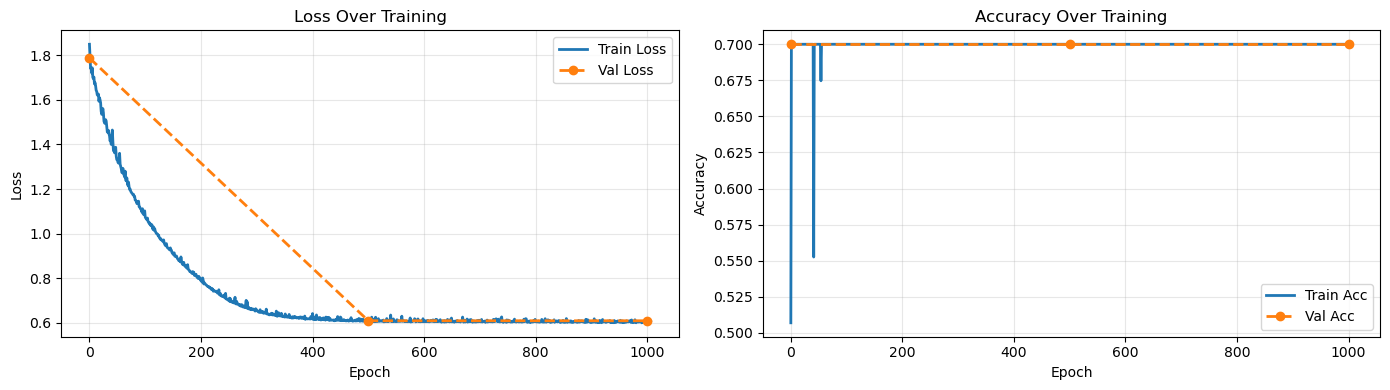


=== TRAINING SUMMARY ===
Final train loss: 0.606628
Final val loss: 0.609079
Best val loss: 0.609032


In [169]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot losses
ax1.plot(train_losses, label='Train Loss', linewidth=2)
if val_losses:
    val_epochs = list(range(0, len(train_losses), config_dict['val_interval']))[:len(val_losses)]
    ax1.plot(val_epochs, val_losses, '--', label='Val Loss', linewidth=2, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Over Training')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot accuracy
ax2.plot(train_accs, label='Train Acc', linewidth=2)
if val_accs:
    val_epochs = list(range(0, len(train_losses), config_dict['val_interval']))[:len(val_accs)]
    ax2.plot(val_epochs, val_accs, '--', label='Val Acc', linewidth=2, marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Over Training')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n=== TRAINING SUMMARY ===")
print(f"Final train loss: {train_losses[-1]:.6f}")
if val_losses:
    print(f"Final val loss: {val_losses[-1]:.6f}")
print(f"Best val loss: {best_loss:.6f}")

In [173]:
## Reconstruction Visualization - Ground Truth vs Prediction

model.eval()
with torch.no_grad():
    sample = train_dataset[0]
    query_points = sample['query_points'].unsqueeze(0).to(device)
    occ_gt = sample['occupancy'].unsqueeze(0).to(device)
    
    inputs = torch.empty(query_points.size(0), 0, device=device)
    c = model.encode_inputs(inputs)
    q_z = model.infer_z(query_points, occ_gt, c)
    z = q_z.rsample()
    logits = model.decode(query_points, z, c).logits
    occ_pred = torch.sigmoid(logits)

occ_gt_np = occ_gt.squeeze().cpu().numpy()
occ_pred_np = occ_pred.squeeze().cpu().numpy()
query_points_np = query_points.squeeze().cpu().numpy()

# Use adaptive threshold based on quantiles
gt_threshold = np.quantile(occ_gt_np, 0.5)
pred_threshold = np.quantile(occ_pred_np, 0.5)

gt_mask = occ_gt_np > gt_threshold
pred_mask = occ_pred_np > pred_threshold

print(f"GT threshold: {gt_threshold:.4f}, GT points: {gt_mask.sum()}")
print(f"Pred threshold: {pred_threshold:.4f}, Pred points: {pred_mask.sum()}")

# Ground Truth Plot
fig1 = go.Figure(data=[go.Scatter3d(x=query_points_np[gt_mask, 0], y=query_points_np[gt_mask, 1], 
                                     z=query_points_np[gt_mask, 2], mode='markers',
                                     marker=dict(size=2, color='blue'))])
fig1.update_layout(title='Ground Truth', scene_aspectmode='data', width=700, height=600)
fig1.show()

# Reconstruction Plot
fig2 = go.Figure(data=[go.Scatter3d(x=query_points_np[pred_mask, 0], y=query_points_np[pred_mask, 1], 
                                     z=query_points_np[pred_mask, 2], mode='markers',
                                     marker=dict(size=2, color='red'))])
fig2.update_layout(title='Reconstruction', scene_aspectmode='data', width=700, height=600)
fig2.show()

GT threshold: 0.0000, GT points: 845
Pred threshold: 0.3402, Pred points: 5000
